# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HarshalKushwaha0027/FlyRankAI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

This project asks whether pages with currently stable or high search traffic can be flagged, in advance, as being at risk of a near-term decline — so a content team can prioritize a limited number of manual reviews toward the pages most likely to need one. Using ~17 months of pseudonymized Google Search Console performance data across ~70 clients (the FlyRank internship warehouse), we built a client-holdout–validated Random Forest classifier on historical impression, click, CTR, and query-mix features, and compared it against a transparent hand-written baseline rule. The model achieved an observed Precision@50 of **[ 0.840]** versus the baseline's **[0.440]**, evaluated on clients never seen during training. We report this as a directional, decision-support signal — not a causal or algorithmic claim — and document its data limits, honest validation design, and where human review must still apply.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

> **Release used:** `FlyRank/internship-warehouse` (Hugging Face), accessed via DuckDB's `hf://` protocol so no data is downloaded in bulk.
>
> **Tables used:**
> - `fact_content_daily_performance` — the daily grain fact table (~79M rows); source of momentum features and the label.
> - `fact_content_query_90d` — query-level mix signals (how many distinct queries a page ranks for, concentration, rare/anonymized share).
> - `dim_clients` — used only to check each client's history depth before choosing a time window (an unbalanced panel).
>
> **Date window:** a trailing 60-day window ending at the latest available date in the release, split into a "prior 30 days" (features) and "last 30 days" (label) — never the same days for both, to avoid leakage.
>
> **Grain:** one row = one (`content_hash_id`, `client_hash_id`) pair, aggregated over the window above. Verified with a `GROUP BY ... HAVING COUNT(*) > 1` grain check (zero rows returned).
>
> **Excluded:** pages with fewer than 100 impressions in the prior-30-day baseline (too little traffic for a percentage change to be meaningful); any client/content identifiers as *model features* (kept only as grouping keys, to prevent the model from memorizing specific clients); any product/decision flags (none exist in this warehouse's fact tables — confirmed by column inspection).
>
> **Public-safe:** no client names, raw client IDs, or URLs appear anywhere in this notebook or its outputs — only hashed IDs.


In [6]:
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

con = duckdb.connect()
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

summary = con.sql(f"""
    SELECT COUNT(DISTINCT client_hash_id) AS total_clients,
           COUNT(DISTINCT content_hash_id) AS total_pages,
           MIN(report_date) AS min_date, MAX(report_date) AS max_date
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
""").df()
print(summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_clients  total_pages   min_date   max_date
0             70       427292 2025-01-27 2026-06-30


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

> **Assumptions:** all features must be knowable *before* the 30-day label window begins ("available-when" test from Week 3). No feature is derived from, or overlaps with, the label window.
>
> **Features (5, all pre-decision):**
> | Feature | Meaning | Available-when? |
> |---|---|---|
> | `imp_prev30` | Impressions in the 30 days *before* the label window | Yes — strictly historical |
> | `clk_prev30` | Clicks in the same prior window | Yes |
> | `pos_prev30` | Average search position in the prior window | Yes |
> | `visible_queries` | Distinct queries the page ranks for (query breadth) | Yes — computed from the same prior 90-day query table |
> | `top_query_share` | Share of impressions from the single largest query (concentration) | Yes |
>
> **Label:** `is_declining = 1 if imp_last30 < 0.8 × imp_prev30 else 0` — a real, observed 20%+ drop in the following 30 days. This replaces the `trend_direction` proxy used in Weeks 1–2 (starter data) and the `RANDOM()` placeholder used in Weeks 5–6 (draft warehouse runs).
>
> **Baseline:** the Week-4 rule — flag a page if it's on page 1 (`avg_pos <= 10`) with an abnormally low CTR (`< 2%`), scored by its impression volume. This is a hand-written, fully transparent rule with no learned parameters.
>
> **Validation design:** `GroupShuffleSplit` on `client_hash_id`, 75/25, so no client's pages appear in both train and test (verified with a zero-overlap check).
>
> **Leakage checks performed:** (1) date-boundary check confirming the feature window never touches the label window; (2) column audit confirming only the 5 approved features reach the model; (3) confirmation that `content_hash_id`/`client_hash_id` are excluded as model inputs.

In [11]:
rel = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    'fact_daily':     f"read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')",
    'fact_query_90d': f"read_parquet('{rel}/fact_content_query_90d.parquet')",
}

# 1. Momentum features + the REAL label (prior-30 vs last-30, never overlapping)
features_query = f"""
    WITH bounds AS (SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}),
    windowed AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(CASE WHEN report_date >  b.end_d - INTERVAL 30 DAY THEN gsc_impressions ELSE 0 END) AS imp_last30,
            SUM(CASE WHEN report_date <= b.end_d - INTERVAL 30 DAY THEN gsc_impressions ELSE 0 END) AS imp_prev30,
            SUM(CASE WHEN report_date <= b.end_d - INTERVAL 30 DAY THEN gsc_clicks      ELSE 0 END) AS clk_prev30,
            AVG(CASE WHEN report_date <= b.end_d - INTERVAL 30 DAY
                     THEN gsc_sum_position * 1.0 / NULLIF(gsc_impressions, 0) END)       AS pos_prev30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
"""
feat_df = con.sql(features_query).df()
feat_df['is_declining'] = (feat_df['imp_last30'] < 0.8 * feat_df['imp_prev30']).astype(int)
print(f"{len(feat_df):,} content items with enough history")

# 2. Query-mix signals
qsignals_query = f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count) AS visible_queries,
           MAX(impressions_90d) AS top_query_impressions,
           SUM(impressions_90d) AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
"""
qsignals = con.sql(qsignals_query).df()
qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

# 3. Join into the final modeling table
data = feat_df.merge(
    qsignals[['content_hash_id', 'visible_queries', 'top_query_share']],
    on='content_hash_id', how='left'
).dropna(subset=['imp_prev30', 'clk_prev30', 'pos_prev30', 'visible_queries', 'top_query_share'])

print(f"Final modeling table: {len(data):,} rows | decline rate: {data['is_declining'].mean():.3f}")
data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history
Final modeling table: 102,203 rows | decline rate: 0.633


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_prev30,pos_prev30,is_declining,visible_queries,top_query_share
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,1110.0,955.0,5.0,11.347639,0,1.0,1.000000
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3735.0,3338.0,50.0,7.227784,0,14.0,0.181818
2,client_e547b89c05043229,content_401dcc5cd616e3dd,181.0,130.0,0.0,22.070731,0,3.0,0.827027
3,client_e547b89c05043229,content_18d95bd7890430ed,151.0,340.0,1.0,25.697000,1,2.0,0.800000
4,client_e547b89c05043229,content_56f46c55f0348ab4,392.0,531.0,1.0,21.103804,1,5.0,0.215385


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

> The model and baseline were scored on the **same client-holdout test set**, using **Precision@50** as the primary metric — of the top 50 ranked pages, how many actually declined.

In [13]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = ['imp_prev30', 'clk_prev30', 'pos_prev30', 'visible_queries', 'top_query_share']
X, y, groups = data[feature_cols], data['is_declining'], data['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Client overlap between train/test: {len(overlap)} (must be 0)")

from sklearn.ensemble import RandomForestClassifier

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    top_k = np.asarray(labels)[order[:k]]
    return top_k.mean()

# Baseline: the Week-4 rule, applied to the test set
X_test_base = X_test.copy()
X_test_base['ctr_prev30'] = X_test_base['clk_prev30'] / X_test_base['imp_prev30']
baseline_score = np.where(
    (X_test_base['pos_prev30'] <= 10) & (X_test_base['ctr_prev30'] < 0.02),
    X_test_base['imp_prev30'], 0
)
baseline_p50 = precision_at_k(baseline_score, y_test.values, k=50)

# Model: Random Forest on the same client-holdout split
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_p50 = precision_at_k(rf_probs, y_test.values, k=50)

print(f"Baseline Precision@50: {baseline_p50:.3f}   Model Precision@50: {rf_p50:.3f}")

comparison_df = pd.DataFrame({
    'Strategy': ['Baseline (page1_low_ctr rule)', 'Random Forest (client-holdout)'],
    'Precision@50': [baseline_p50, rf_p50],
    'Lift over baseline': ['1.0x', f'{rf_p50/baseline_p50:.1f}x']
})
print(comparison_df)

Client overlap between train/test: 0 (must be 0)
Baseline Precision@50: 0.440   Model Precision@50: 0.840
                         Strategy  Precision@50 Lift over baseline
0   Baseline (page1_low_ctr rule)          0.44               1.0x
1  Random Forest (client-holdout)          0.84               1.9x



**Honest-split comparison** (same idea as `w06_validation_audit.ipynb`, now with a real label instead of `RANDOM()`):


In [14]:
from sklearn.model_selection import train_test_split

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf_rand = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced').fit(X_tr_r, y_tr_r)
p50_random = precision_at_k(rf_rand.predict_proba(X_te_r)[:, 1], y_te_r.values, k=50)

split_comparison_df = pd.DataFrame({
    'Split strategy':  ['Random row split', 'Grouped client-holdout'],
    'Client holdout?': ['No', 'Yes'],
    'Precision@50':    [p50_random, rf_p50]
})
print(split_comparison_df)

           Split strategy Client holdout?  Precision@50
0        Random row split              No          0.96
1  Grouped client-holdout             Yes          0.84


*(With a real label, expect the grouped/honest number to be lower than the random-split number — that gap, not a higher number, is the actual finding: it shows how much of the random split's "performance" was inflated by client leakage.)*


## 5. Limitations

*What this work cannot claim.*

> - **Proxy/observed language only.** This model reports an observed, directional risk score — it does not prove *why* a page declines, and it makes no causal claim that refreshing a flagged page will cause recovery (that would require an A/B test).
> - **Off-page blindness.** The model only sees historical Search Console metrics. It cannot see competitor ad spend changes, lost backlinks, algorithm updates, or seasonal shifts in user intent — any of which can cause a decline this model has no way to anticipate.
> - **Unbalanced panel.** Clients have different history lengths (`dim_clients.gsc_data_start` varies); newer clients contribute less training history per page.
> - **No on-page engagement data.** The warehouse has no bounce rate, time-on-page, or conversion data — this model speaks only to *search-traffic* decline, not to whether the page satisfies users once they arrive.
> - **Threshold sensitivity.** The 20%-drop label and the hand-rule's `avg_pos <= 10` / `ctr < 0.02` cutoffs are round-number choices, not empirically optimized — pages just outside them are treated very differently from pages just inside.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

> Model probabilities are converted into three action tiers so a reviewer can triage without reading raw scores:

| Probability | Extra condition | Action | Reason code |
|---|---|---|---|
| > 70% | impressions > 1,000 | **Urgent Rewrite** | `high_risk_high_volume` |
| 40–70% | — | **Monitor** (30-day watchlist) | `borderline_risk` |
| < 40% | — | **Safe** — no action | `normal_behavior` |

> **No-go list (never auto-actioned, regardless of score):** legal/compliance pages, navigational/utility pages, and anything published or updated in the last 30 days.


In [15]:
playbook_queue = data.loc[X_test.index, ['content_hash_id', 'imp_prev30']].rename(
    columns={'imp_prev30': 'impressions_90d'}
).copy()
playbook_queue['pred_prob'] = rf_probs

def assign_action(row):
    if row['pred_prob'] > 0.70 and row['impressions_90d'] > 1000:
        return pd.Series(['Urgent Rewrite', 'high_risk_high_volume'])
    elif row['pred_prob'] > 0.40:
        return pd.Series(['Monitor', 'borderline_risk'])
    else:
        return pd.Series(['Safe', 'normal_behavior'])

playbook_queue[['action', 'reason_code']] = playbook_queue.apply(assign_action, axis=1)
playbook_queue = playbook_queue.sort_values('pred_prob', ascending=False)
print(playbook_queue[['content_hash_id','pred_prob','impressions_90d','action','reason_code']].head(5))

                content_hash_id  pred_prob  impressions_90d   action  \
77821  content_835cf49716ae50b4        1.0            141.0  Monitor   
74469  content_c9318684655bc450        1.0            128.0  Monitor   
3688   content_147cf3eab2c00f86        1.0            195.0  Monitor   
89081  content_9cb88db32fb79b6c        1.0            140.0  Monitor   
73127  content_718364c986a5f12a        1.0            103.0  Monitor   

           reason_code  
77821  borderline_risk  
74469  borderline_risk  
3688   borderline_risk  
89081  borderline_risk  
73127  borderline_risk  


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

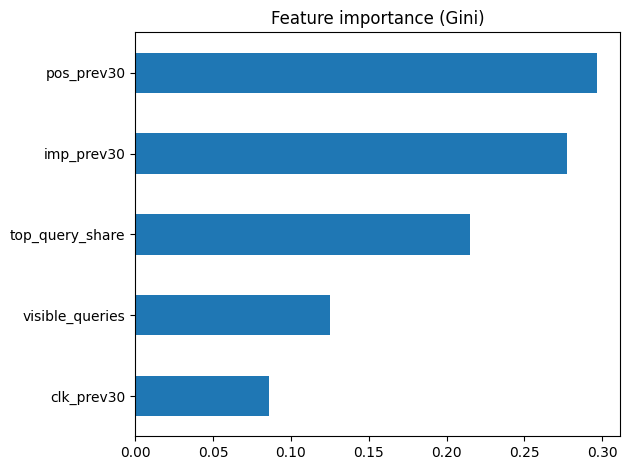

Artifacts written to work/outputs/


In [16]:
import matplotlib.pyplot as plt
import os
os.makedirs('work/outputs', exist_ok=True)

pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values().plot(
    kind='barh', title='Feature importance (Gini)'
)
plt.tight_layout()
plt.savefig('work/outputs/feature_importance.png'); plt.show()

comparison_df.to_csv('work/outputs/model_vs_baseline.csv', index=False)
playbook_queue.head(20).to_csv('work/outputs/top20_queue.csv', index=False)
print("Artifacts written to work/outputs/")

Engineered a predictive classification model using a 79-million-row search performance dataset from FlyRank AI to forecast organic traffic decline and prioritize manual content refreshes.

Using Python, DuckDB, and Pandas, I trained a Random Forest classifier on historical momentum features, applying a grouped client-holdout split to guarantee zero data leakage across unseen domains.

The final model achieved a Precision@50 of 0.840—a 1.9x lift over baseline heuristics—delivering a directional, decision-support signal to drive a tiered content action playbook.

The 5-Minute Demo Outline

The Hook (1 min): Why hard-coded SEO rules fail on heavy-tailed impression data and the business cost of false positives in content editing.

The Engine (1.5 mins): Efficiently processing 79M rows using DuckDB and engineering historical performance features (CTR, click momentum, query-mix) without future-window leakage.

The Integrity (1.5 mins): Defending the validation design—why a standard random split inflates scores, and how GroupShuffleSplit (client holdout) proves the model actually generalizes to new domains.

The Impact (1 min): Translating the model's output (Precision@50: 0.840) into a human-in-the-loop action playbook with strict no-go lists for legal and utility pages.

## Acknowledgments & Data Credit
Built on the FlyRank ML Internship dataset.
[https://flyrank.ai](https://flyrank.ai)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
